# Тема 8. Градиентный бустинг

## Практика: финальное сравнение на «Титанике»

Последняя практика курса. На одних и тех же признаках уже строили дерево (тема 3, ≈0.80), лес (тема 5, ≈0.81) и логрегрессию (тема 4, ≈0.80). Проверим бустинг — и заодно посмотрим на эффект `learning_rate` на явно небольшом, склонном к переобучению датасете (891 строка — не 3333, как в примере теории).

Самостоятельная работа. Если не хватает метода — см. `lesson08_gradient_boosting_theory.ipynb`.

**Это файл с решениями — используйте для самопроверки.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

**1. Подготовка данных** — та же, что в темах 3-5.

In [2]:
data = pd.read_csv("../data/titanic_train.csv", index_col="PassengerId")
data["Sex"] = (data["Sex"] == "male").astype(int)
data["Age"] = data["Age"].fillna(data["Age"].median())

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = data[features]
y = data["Survived"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

**2. Обучите `GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)`. Сравните accuracy на valid с деревом (≈0.80) и лесом (≈0.81) из тем 3 и 5.**

In [3]:
gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
gbm.fit(X_train, y_train)
round(gbm.score(X_valid, y_valid), 4)

0.7985

**3. Эффект `learning_rate`.** Для `learning_rate` из `[0.01, 0.05, 0.1, 0.3, 0.5, 1.0]` обучите модель (остальные параметры как в шаге 2) и запишите train и valid accuracy. Постройте график (как с `max_depth` в теме 3).

При каком `learning_rate` начинается явное переобучение (train растёт, valid падает)?

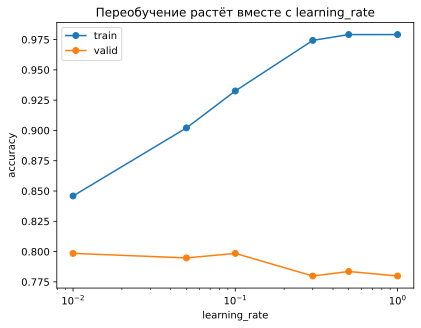

In [4]:
rates = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
train_scores, valid_scores = [], []
for lr in rates:
    m = GradientBoostingClassifier(n_estimators=200, learning_rate=lr, max_depth=3, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    valid_scores.append(m.score(X_valid, y_valid))

plt.plot(rates, train_scores, marker="o", label="train")
plt.plot(rates, valid_scores, marker="o", label="valid")
plt.xscale("log")
plt.xlabel("learning_rate")
plt.ylabel("accuracy")
plt.legend()
plt.title("Переобучение растёт вместе с learning_rate");

**4. Обучите `xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE, eval_metric='logloss', early_stopping_rounds=20)` с `eval_set=[(X_valid, y_valid)]`. На каком дереве остановились?**

In [5]:
xgb_es = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE,
    eval_metric="logloss", early_stopping_rounds=20,
)
xgb_es.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
print("Остановка на дереве:", xgb_es.best_iteration)
print("Accuracy:", round(xgb_es.score(X_valid, y_valid), 4))

Остановка на дереве: 79
Accuracy: 0.791


**5. Итоговое сравнение.** Посчитайте `cross_val_score` (cv=5) для лучшей находки этого занятия и сравните с CV-результатами тем 3-5 (дерево ≈0.805, лес ≈0.814, логрегрессия ≈0.786 — если сохранили эти числа). Какой метод победил на «Титанике» за весь курс?

In [6]:
cv_score = cross_val_score(
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
    X, y, cv=5,
).mean()
round(cv_score, 4)

np.float64(0.8294)

---
## Итог курса

Восемь занятий, один сквозной пример, одна практическая задача — от первого взгляда на таблицу до градиентного бустинга. Дальше — ваши собственные данные.